In [1]:
import pandas as pd 
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import re
import ast

In [2]:
files = "../dataset_features/imports.csv"
all_files="../dataset_features/files_raw.csv"
source = "../backups/exp_no_hist.csv"
names = ["Vibecoding", "SideProject"]

In [3]:
files_df = pd.read_csv(files, names= ["url", "commit", "project", "file_path", "file", "imports"])
files_df.drop_duplicates(inplace=True)
source_df = pd.read_csv(source)
source_df.drop_duplicates(inplace=True)

In [4]:
files_df.head()

,url,commit,project,file_path,file,imports
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,set()
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,set()
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}"
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}"
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a..."


In [5]:
files_df.head()

,url,commit,project,file_path,file,imports
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,set()
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,set()
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}"
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}"
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a..."


In [6]:
print(len(files_df))

17529


In [7]:
#print(files_df[""][int(comments.index[comments.proj_name == "Anubis"].max())])
print("prompt-library/tools/adhd-optimizer/optimize.py" in list(files_df.file_path))

True


# Stats on groups

In [8]:
def make_mask(df_source, df_files, name):  
    mask = (df_source[name])
    name_df = df_source[mask]
    url_set = set(name_df["url"])
    mask = (df_files["url"].isin(url_set))
    masked_files = df_files[mask]
    return masked_files

In [9]:
df_vc = make_mask(source_df, files_df, names[0])
df_sp = make_mask(source_df, files_df, names[1])

In [10]:
df_sp["source"] = "SideProject"
df_vc["source"] = "Vibecoding"

df_all = pd.concat([df_sp, df_vc], ignore_index=True)
df_all.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,set(),SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,set(),SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}",SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a...",SideProject


In [11]:
#print(df_all["source"][int(df_all.index[df_all.proj_name == "Anubis"].max())])
print(df_all["source"][int(df_all.index[df_all.project == "Ben-s-Software-"].max())])

Vibecoding


In [12]:
print("prompt-library/tools/adhd-optimizer/optimize.py" in list(df_all.file_path))

True


In [13]:
print(f"number vibecoded projects with imports: {len(df_vc.url.unique())}")
print(f"number sideproject projects with imports: {len(df_sp.url.unique())}")
print(f"number vibecoded files with imports: {len(df_vc.file_path.unique())}")
print(f"number sideproject files with imports: {len(df_sp.file_path.unique())}")

number vibecoded projects with imports: 169
number sideproject projects with imports: 152
number vibecoded files with imports: 12474
number sideproject files with imports: 5055


In [14]:
all

<function all(iterable, /)>

## Files with no imports

In [15]:
failed_files = pd.read_csv("../dataset_features/clone_failures.csv", names=["url", "proj_name", "file_path", "reason"])
#failed_files.drop_duplicates(inplace=True, keep="first")

In [16]:
failed_files.head()

,url,proj_name,file_path,reason
0,https://github.com/Skowt/Loadr,Loadr,Loadr/img/icon.png,failed reading file: 'utf-8' codec can't decod...
1,https://github.com/Skowt/Loadr,Loadr,Loadr/img/glyphicons-halflings.png,failed reading file: 'utf-8' codec can't decod...
2,https://github.com/Skowt/Loadr,Loadr,Loadr/img/glyphicons-halflings-white.png,failed reading file: 'utf-8' codec can't decod...
3,https://github.com/Skowt/Loadr,Loadr,Loadr/.git/index,failed reading file: 'utf-8' codec can't decod...
4,https://github.com/Skowt/Loadr,Loadr,Loadr/.git/objects/pack/pack-9c8e030d4577c1fa4...,failed reading file: 'utf-8' codec can't decod...


In [17]:
error_files = set(failed_files["file_path"])
all_py = [ s for s in failed_files.proj_name if r".py,$" in s]
print("prompt-library/.git/index" in list(failed_files.file_path))
"prompt-library/tools/adhd-optimizer/optimizer.py" in list(failed_files.file_path)

True


True

In [18]:
print(type(failed_files.file_path.iloc[0]))

<class 'str'>


In [19]:
all_py

[]

In [20]:
all_files_df = pd.read_csv(all_files, names=["url", "proj_name", "file_path", "file_name", "extn", "n_lines", "blank_lines", "char"])
all_files_df.drop_duplicates(inplace=True)

all_files_py = all_files_df[all_files_df["extn"] == "py"]

py_vc = make_mask(source_df, all_files_py, names[0])
py_sp = make_mask(source_df, all_files_py, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

py_all = pd.concat([py_sp, py_vc], ignore_index=True)
py_all

,url,proj_name,file_path,file_name,extn,n_lines,blank_lines,char,source
0,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/__init__.py,__init__.py,py,0,0,0,SideProject
1,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,py,0,0,0,SideProject
2,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,py,36,8,626,SideProject
3,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,py,1,0,26,SideProject
4,https://github.com/GusSand/Anubis,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,py,137,28,3827,SideProject
...,...,...,...,...,...,...,...,...,...
17538,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/__i...,__init__.py,py,48,8,1494,Vibecoding
17539,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sys...,system_management_service.py,py,423,80,11348,Vibecoding
17540,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/bas...,base_service.py,py,140,31,2629,Vibecoding
17541,https://github.com/johnhuang316/code-index-mcp,code-index-mcp,code-index-mcp/src/code_index_mcp/services/cod...,code_intelligence_service.py,py,245,43,5991,Vibecoding


In [21]:
df_all.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,set(),SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,set(),SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}",SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a...",SideProject


In [22]:
# Define a dictionary for remapping values
d = {"set()":0}

# Remap the values using replace()
df_all['imports'] = df_all['imports'].replace(d)

In [23]:
df_all.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,0,SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,0,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}",SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a...",SideProject


In [24]:
all_more_zero = df_all[df_all["imports"] != 0]

In [25]:
print(len(df_all))
print(len(all_more_zero))

17529
15786


In [26]:
print(len(all_more_zero.groupby("source").get_group("SideProject").url.unique())) #.get_group("SideProject").url.unique()
print(len(all_more_zero.groupby("source").get_group("SideProject").file_path.unique()))
print()

print(len(all_more_zero.groupby("source").get_group("Vibecoding").url.unique())) #.get_group("SideProject").url.unique()
print(len(all_more_zero.groupby("source").get_group("Vibecoding").file_path.unique()))

152
4490

169
11296


In [27]:
i_source = source_df.set_index("url")
i_source.head()

,Unnamed: 0,commit,error,time_out,SideProject,Vibecoding
url,,,,,,
https://github.com/Skowt/Loadr,0,c2ead4af6a33aed6ed79684f2346de6a3f12fe5a,False,False,True,False
https://github.com/AI-Spawn/Save-The-Turtles,1,4747b9d40aeb6c1cbc73eb0802008c4afff686d9,False,False,True,False
https://github.com/YigitGunduc/cycle,2,26eb2a3b4b61505b7f21395e0165a1cee3973090,False,False,True,False
https://github.com/saurabh0719/jett,3,3f57c4a8a626678f27305c54d13237eb583c30b4,False,False,True,False
https://github.com/tn/climood,4,4dae3cae768245a169e8abeccb457558fac8c112,False,False,True,False


In [28]:
df_path_url=df_all

In [29]:
df_zero = df_path_url[df_path_url.imports == 0]

In [30]:
print("prompt-library/tools/adhd-optimizer/optimizer.py" in list(df_zero.file_path))

False


In [31]:
df_zero_sp = df_zero[df_zero.source == "SideProject"]
df_zero_vc = df_zero[df_zero.source == "Vibecoding"]

In [32]:
print(len(df_zero_sp))

565


In [33]:
print("prompt-library/tools/adhd-optimizer/optimizer.py" in list(df_zero_vc.file_path))

False


In [34]:
df_zero_vc["link"] = df_zero_vc.url + "/blob/" + df_zero_vc.commit + "/"+ df_zero_vc.file_path.str.split("/", n=1).str[1]

In [35]:
num = 2
print(df_zero_vc.link.iloc[num], df_zero_vc.file_path.iloc[num])

https://github.com/jbdamask/scratch/blob/8e927149a250e44f09756f7fdf6d7db04b2a2623/TOOLS/privacy-policy-reviewer/prompts.py scratch/TOOLS/privacy-policy-reviewer/prompts.py


# Extracting out the import statements

### Total number of imports

In [36]:
files_df.head()

,url,commit,project,file_path,file,imports
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,set()
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,set()
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}"
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}"
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a..."


In [37]:
df_all.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,0,SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,0,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{'dataclasses', 'enum', 're'}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,"{""autograde.app: ['app']""}",SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{""autograde.utils: ['RejectionException']"", ""a...",SideProject


In [38]:
files_df["imports"] = files_df["imports"].apply(ast.literal_eval)

In [39]:
counts = files_df["imports"].explode().value_counts()

In [40]:
counts

imports
pathlib: ['Path']                                                 3657
os                                                                3228
logging                                                           3017
sys                                                               2352
json                                                              2327
                                                                  ... 
tools.config: ['ProjectConfigTool', 'SettingsTool']                  1
utils: ['ContextHelper', 'ValidationHelper']                         1
tools.filesystem: ['FileSystemTool']                                 1
search.base: ['is_safe_regex_pattern']                               1
utils: ['FileFilter', 'ResponseFormatter', 'ValidationHelper']       1
Name: count, Length: 27148, dtype: int64

### Imports by source

In [41]:
py_vc = make_mask(source_df, files_df, names[0])
py_sp = make_mask(source_df, files_df, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

py_import = pd.concat([py_sp, py_vc], ignore_index=True)
py_import

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,{},SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,{},SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{re, dataclasses, enum}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,{autograde.app: ['app']},SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{os, autograde.utils: ['RejectionException'], ...",SideProject
...,...,...,...,...,...,...,...
17524,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/__i...,__init__.py,"{file_service: ['FileService'], search_service...",Vibecoding
17525,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sys...,system_management_service.py,{index_management_service: ['IndexManagementSe...,Vibecoding
17526,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/bas...,base_service.py,"{utils: ['ContextHelper', 'ValidationHelper'],...",Vibecoding
17527,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/cod...,code_intelligence_service.py,"{os, logging, base_service: ['BaseService'], i...",Vibecoding


In [42]:
print(py_import["source"][int(py_import.index[py_import.project == "Anubis"].max())])
print(py_import["source"][int(py_import.index[py_import.project == "Ben-s-Software-"].max())])

SideProject
Vibecoding


#### Percentage of total imports each individual import statement makes up

In [43]:
counts_sp = py_import.groupby("source").get_group("SideProject")["imports"].explode().value_counts()
counts_vc = py_import.groupby("source").get_group("Vibecoding")["imports"].explode().value_counts()

In [44]:
counts_sp

imports
__future__: ['unicode_literals']                                                                                                       850
re                                                                                                                                     783
common: ['InfoExtractor']                                                                                                              729
os                                                                                                                                     718
sys                                                                                                                                    501
                                                                                                                                      ... 
inquirer                                                                                                                                 1
synko.constants: ['

In [45]:
counts_vc

imports
pathlib: ['Path']                                                 3570
logging                                                           2601
os                                                                2510
__future__: ['annotations']                                       2187
json                                                              2027
                                                                  ... 
tools.config: ['ProjectConfigTool', 'SettingsTool']                  1
utils: ['ContextHelper', 'ValidationHelper']                         1
tools.filesystem: ['FileSystemTool']                                 1
search.base: ['is_safe_regex_pattern']                               1
utils: ['FileFilter', 'ResponseFormatter', 'ValidationHelper']       1
Name: count, Length: 19822, dtype: int64

In [46]:
counts_all = pd.concat([counts_vc, counts_sp], axis=1).fillna(0)

In [47]:
counts_all.columns = ["Vibecoding", "SideProject"]

In [48]:
counts_all["sum"] = counts_all["Vibecoding"] + counts_all["SideProject"]

In [49]:
counts_all["p_vibecoding"] = counts_all["Vibecoding"]/(counts_all["Vibecoding"].sum())
counts_all["p_sideProject"] = counts_all["SideProject"]/(counts_all["SideProject"].sum())

In [50]:
counts_all = counts_all.sort_values(by = ["sum"], ascending = False) 

In [51]:
counts_all

,Vibecoding,SideProject,sum,p_vibecoding,p_sideProject
imports,,,,,
pathlib: ['Path'],3570.0,87.0,3657.0,0.046244,0.003341
os,2510.0,718.0,3228.0,0.032513,0.027570
logging,2601.0,416.0,3017.0,0.033692,0.015974
sys,1851.0,501.0,2352.0,0.023977,0.019237
json,2027.0,300.0,2327.0,0.026256,0.011519
...,...,...,...,...,...
vibe_core.mahamantra.research.gita_verse_text: ['KALI_YUGA_PERCENTAGE'],1.0,0.0,1.0,0.000013,0.000000
vibe_core.mahamantra.research.gita_verse_text: ['BG_18_66_GURU_COUNT'],1.0,0.0,1.0,0.000013,0.000000
vibe_core.mahamantra.research.gita_verse_text: ['MAHAMANTRA_HALF_BINARY'],1.0,0.0,1.0,0.000013,0.000000


In [52]:
df_counts = counts_all.drop(["sum", "Vibecoding", "SideProject"], axis=1)
df_counts

,p_vibecoding,p_sideProject
imports,,
pathlib: ['Path'],0.046244,0.003341
os,0.032513,0.027570
logging,0.033692,0.015974
sys,0.023977,0.019237
json,0.026256,0.011519
...,...,...
vibe_core.mahamantra.research.gita_verse_text: ['KALI_YUGA_PERCENTAGE'],0.000013,0.000000
vibe_core.mahamantra.research.gita_verse_text: ['BG_18_66_GURU_COUNT'],0.000013,0.000000
vibe_core.mahamantra.research.gita_verse_text: ['MAHAMANTRA_HALF_BINARY'],0.000013,0.000000


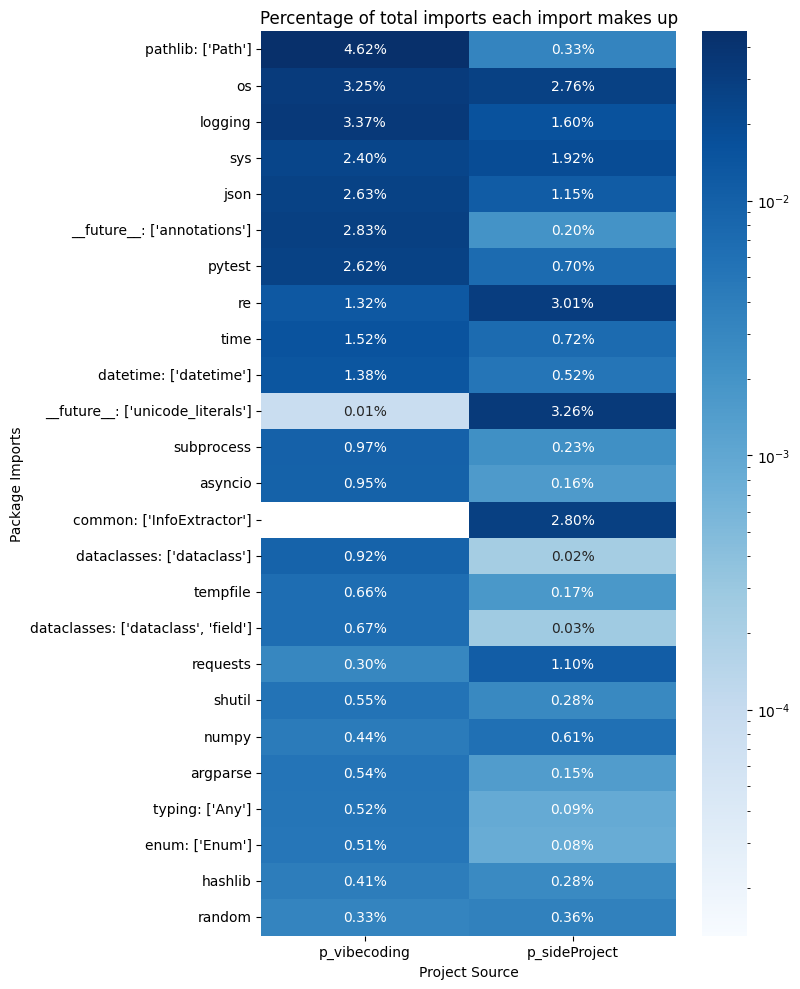

In [53]:
plt.figure(figsize=(8, 10))
sns.heatmap(
df_counts[:25],
annot=True,
fmt=".2%",
cmap="Blues",
norm=LogNorm(vmin=max(0, df_counts[df_counts > 0].min().min()),
                vmax=df_counts.max().max())
)
plt.title("Percentage of total imports each import makes up")
plt.xlabel("Project Source")
plt.ylabel("Package Imports")
plt.tight_layout()
plt.show()

### Percent of files each import shows up in

In [54]:
py_import.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,{},SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,{},SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{re, dataclasses, enum}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,{autograde.app: ['app']},SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{os, autograde.utils: ['RejectionException'], ...",SideProject


In [55]:
df_expanded  = py_import.explode("imports")

In [56]:
df_exploded = df_expanded.groupby(["source", "imports"]).size().reset_index(name="n_times")

In [57]:
heatmap_df = df_exploded.pivot(index='imports', columns='source', values='n_times').fillna(0)
heatmap_df.head()

source,SideProject,Vibecoding
imports,,
AnalyzeError: ['AnalyzeError'],0.0,1.0
AppKit,0.0,2.0
AppKit: ['NSScreen'],0.0,1.0
Apprise: ['Apprise'],1.0,0.0
AppriseAsset: ['AppriseAsset'],7.0,0.0


In [58]:
heatmap_df["sum"] = heatmap_df["Vibecoding"] + heatmap_df["SideProject"]
heatmap_df = heatmap_df.sort_values(by = ["sum"], ascending = False) 
heatmap_df["p_vibecoding"] = heatmap_df["Vibecoding"]/(len(all_more_zero.groupby("source").get_group("Vibecoding").file_path.unique()))
heatmap_df["p_sideProject"] = heatmap_df["SideProject"]/(len(all_more_zero.groupby("source").get_group("SideProject").file_path.unique()))

In [59]:
heatmap_df.head()

source,SideProject,Vibecoding,sum,p_vibecoding,p_sideProject
imports,,,,,
pathlib: ['Path'],87.0,3570.0,3657.0,0.316041,0.019376
os,718.0,2510.0,3228.0,0.222203,0.159911
logging,416.0,2601.0,3017.0,0.230258,0.092650
sys,501.0,1851.0,2352.0,0.163863,0.111581
json,300.0,2027.0,2327.0,0.179444,0.066815


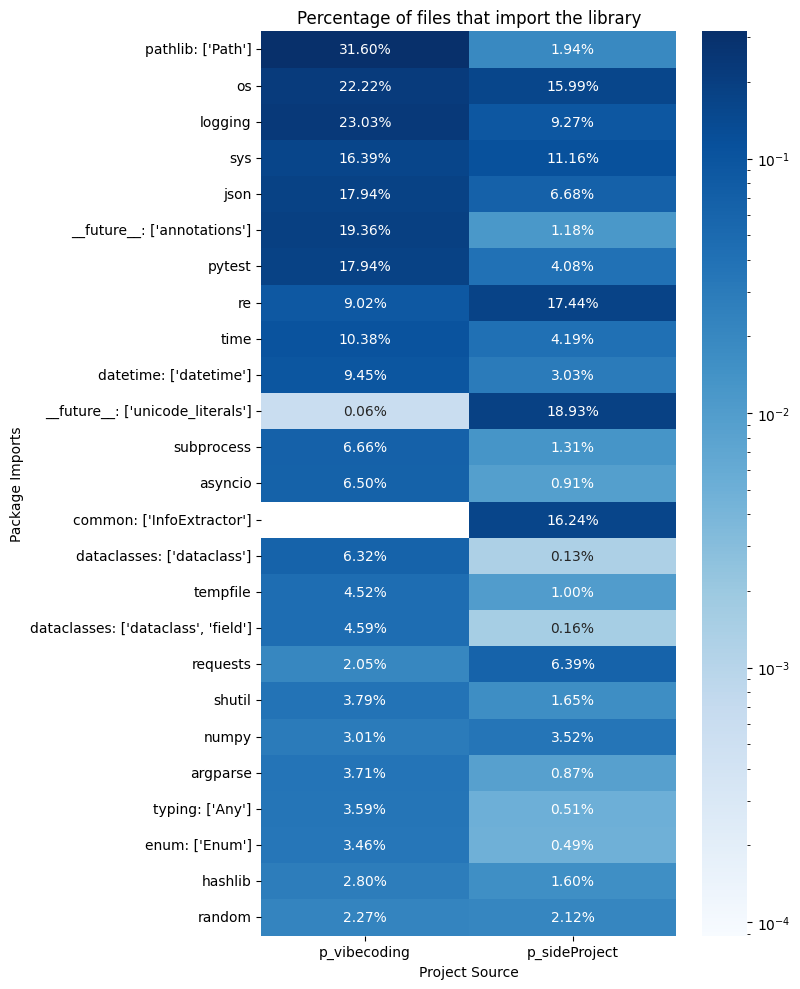

In [60]:
df = heatmap_df.drop(["SideProject", "Vibecoding", "sum"], axis=1)
plt.figure(figsize=(8, 10))
sns.heatmap(
df[:25],
annot=True,
fmt=".2%",
cmap="Blues",
norm=LogNorm(vmin=max(0, df[df > 0].min().min()),
                vmax=df.max().max())
)
plt.title("Percentage of files that import the library")
plt.xlabel("Project Source")
plt.ylabel("Package Imports")
plt.tight_layout()
plt.show()

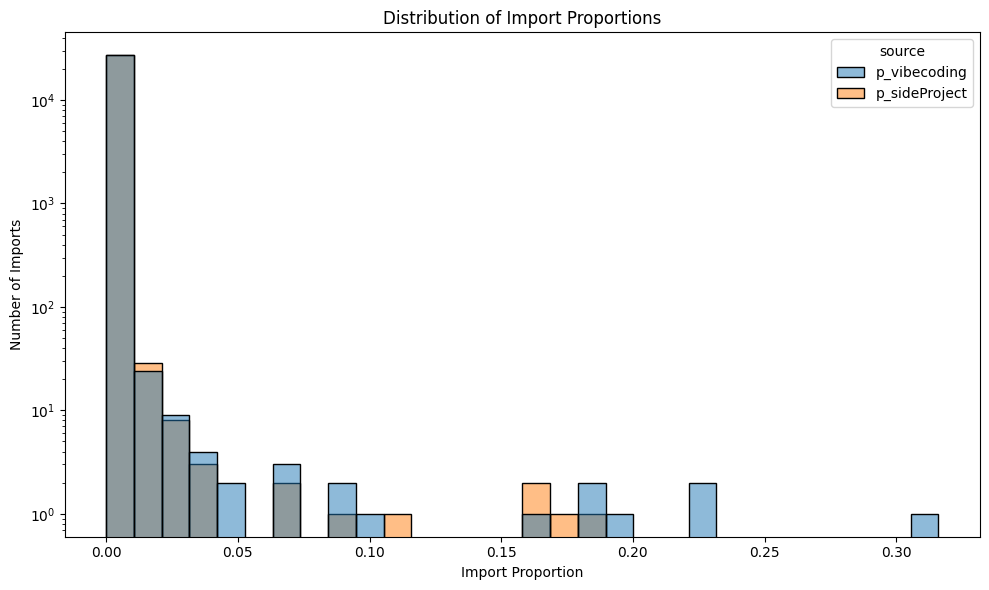

In [ ]:
plot_df = heatmap_df.reset_index().melt(
    id_vars="imports",
    value_vars=["p_vibecoding", "p_sideProject"],
    var_name="source",
    value_name="proportion"
)

# Plot
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x="proportion",
    hue="source",
    multiple="dodge",
    bins=30,
    stat="count",
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Import Proportion")
plt.ylabel("Number of Times Proportion Appears")
plt.title("The number of times a import appears in a given percentage of files")
plt.yscale("log")
plt.tight_layout()
plt.show()

### Number of imports per file

In [62]:
py_import.head()

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,{},SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,{},SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,"{re, dataclasses, enum}",SideProject
3,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/__init__.py,__init__.py,{autograde.app: ['app']},SideProject
4,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/exercise.py,exercise.py,"{os, autograde.utils: ['RejectionException'], ...",SideProject


In [63]:
df_expanded  = py_import.explode("imports")

In [64]:
df_expanded

,url,commit,project,file_path,file,imports,source
0,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/__init__.py,__init__.py,NaN,SideProject
1,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/__init__.py,__init__.py,NaN,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,re,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,dataclasses,SideProject
2,https://github.com/GusSand/Anubis,dced3375debfbe06362d2da03f71ea80b29fb81b,Anubis,Anubis/theia/autograde/autograde/models.py,models.py,enum,SideProject
...,...,...,...,...,...,...,...
17528,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sea...,search_service.py,search.base: ['is_safe_regex_pattern'],Vibecoding
17528,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sea...,search_service.py,"utils: ['FileFilter', 'ResponseFormatter', 'Va...",Vibecoding
17528,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sea...,search_service.py,"typing: ['Any', 'Dict', 'List', 'Optional', 'T...",Vibecoding
17528,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,code-index-mcp,code-index-mcp/src/code_index_mcp/services/sea...,search_service.py,base_service: ['BaseService'],Vibecoding


In [71]:
df_counts = df_expanded.groupby(["source", "project", "file_path"]).size().reset_index(name="n_times")

In [76]:
df_counts.groupby(["source", "n_times"]).size()

source       n_times
SideProject  1          1130
             2           585
             3           685
             4           630
             5           470
                        ... 
Vibecoding   90            1
             92            1
             107           1
             111           1
             135           1
Length: 109, dtype: int64

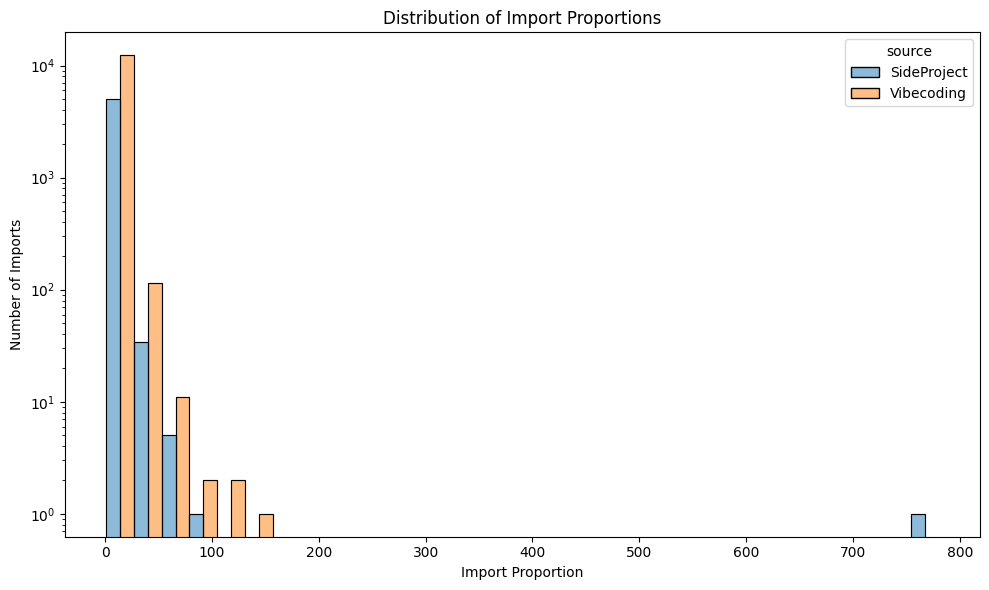

In [75]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_counts,
    x="n_times",
    hue="source",
    multiple="dodge",
    bins=30,
    stat="count",
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Import Proportion")
plt.ylabel("Number of Imports")
plt.title("Distribution of Import Proportions")
plt.yscale("log")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Number of imports per file')

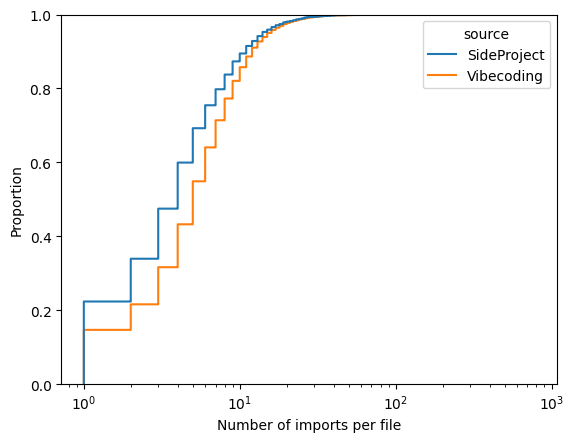

In [79]:
sns.ecdfplot(data=df_counts,
    x="n_times",
    hue="source", stat="proportion", log_scale=True)
plt.xlabel("Number of imports per file")

In [ ]:
from scipy.stats import mannwhitneyu


KeyboardInterrupt: 

In [81]:
vc = df_counts[df_counts["source"] == "Vibecoding"]["n_times"]
sp = df_counts[df_counts["source"] == "SideProject"]["n_times"]



In [82]:
U1, p = mannwhitneyu(vc, sp, method="exact")
print(p)

KeyboardInterrupt: 

In [83]:
U1, p = mannwhitneyu(vc, sp, alternative='two-sided')
print(p)

1.271031013772877e-85


In [84]:
U1, p = mannwhitneyu( sp, vc, alternative='two-sided')
print(p)

1.271031013772877e-85


In [ ]:
sp.mean()

np.float64(5.263699307616221)

In [86]:
vc.mean()

np.float64(6.283309283309284)

In [ ]:
import effectsize

# Assuming df is a Pandas DataFrame with your data
result = effectsize.compute(data=df_counts, group='group_column', continuous=['variable1', 'variable2'])

In [ ]:
df_counts

## Number of times import is used